<a href="https://colab.research.google.com/github/venkata18167/CSA6301---THREAT-INTELLIGENCE-AND-NETWORK-SECURITY/blob/main/26_Simulating_Splunk_Style_Search_(SPL)_and_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Security Logs Created Successfully.

Security Logs

             Timestamp    IP Address Username   Status
0  2026-08-03 10:00:01  192.168.1.10    admin   FAILED
1  2026-08-03 10:00:15  192.168.1.10    admin   FAILED
2  2026-08-03 10:01:10  192.168.1.20     john  SUCCESS
3  2026-08-03 10:02:00  192.168.1.30    alice   FAILED
4  2026-08-03 10:02:20  192.168.1.20     john   FAILED
5  2026-08-03 10:03:10  192.168.1.40     root  SUCCESS
6  2026-08-03 10:04:05  192.168.1.10    admin   FAILED
7  2026-08-03 10:05:20  192.168.1.30    alice  SUCCESS
8  2026-08-03 10:06:15  192.168.1.50    guest   FAILED
9  2026-08-03 10:07:30  192.168.1.20     john   FAILED

SPL QUERY
search Status=FAILED

             Timestamp    IP Address Username  Status
0  2026-08-03 10:00:01  192.168.1.10    admin  FAILED
1  2026-08-03 10:00:15  192.168.1.10    admin  FAILED
3  2026-08-03 10:02:00  192.168.1.30    alice  FAILED
4  2026-08-03 10:02:20  192.168.1.20     john  FAILED
6  2026-08-03 10:04:05  192.168.1

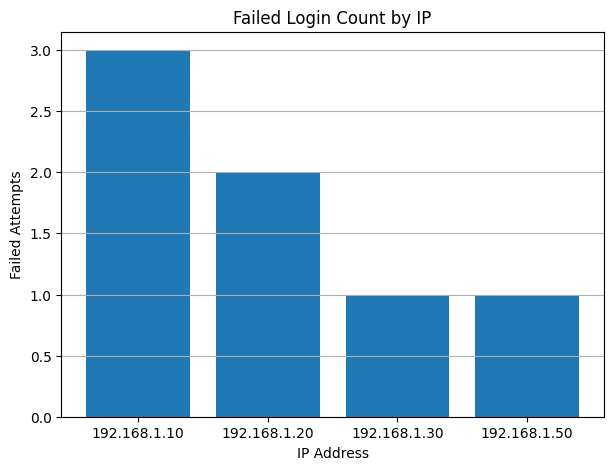


========== FINAL REPORT ==========
Total Log Entries : 10
Failed Logins : 7
Successful Logins : 3
Unique IP Addresses : 5

Simulation Completed Successfully.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

logs = [
["2026-08-03 10:00:01","192.168.1.10","admin","FAILED"],
["2026-08-03 10:00:15","192.168.1.10","admin","FAILED"],
["2026-08-03 10:01:10","192.168.1.20","john","SUCCESS"],
["2026-08-03 10:02:00","192.168.1.30","alice","FAILED"],
["2026-08-03 10:02:20","192.168.1.20","john","FAILED"],
["2026-08-03 10:03:10","192.168.1.40","root","SUCCESS"],
["2026-08-03 10:04:05","192.168.1.10","admin","FAILED"],
["2026-08-03 10:05:20","192.168.1.30","alice","SUCCESS"],
["2026-08-03 10:06:15","192.168.1.50","guest","FAILED"],
["2026-08-03 10:07:30","192.168.1.20","john","FAILED"]
]

df = pd.DataFrame(logs, columns=[
    "Timestamp",
    "IP Address",
    "Username",
    "Status"
])

df.to_csv("Security_Logs.csv", index=False)

print("Sample Security Logs Created Successfully.\n")

print("Security Logs\n")
print(df)

failed_logs = df[df["Status"] == "FAILED"]

print("\n===================================")
print("SPL QUERY")
print("search Status=FAILED")
print("===================================\n")

print(failed_logs)


stats = failed_logs.groupby("IP Address").size().reset_index(name="Failed Count")

print("\n===================================")
print("SPL QUERY")
print("search Status=FAILED | stats count by IP Address")
print("===================================\n")

print(stats)

top_ip = stats.sort_values(by="Failed Count", ascending=False).head(1)

print("\nMost Suspicious IP Address\n")
print(top_ip)

stats.to_csv("SPL_Report.csv", index=False)

print("\nReport saved as SPL_Report.csv")

plt.figure(figsize=(7,5))

plt.bar(stats["IP Address"], stats["Failed Count"])

plt.title("Failed Login Count by IP")
plt.xlabel("IP Address")
plt.ylabel("Failed Attempts")

plt.grid(axis='y')

plt.show()

print("\n========== FINAL REPORT ==========")

print("Total Log Entries :", len(df))
print("Failed Logins :", len(failed_logs))
print("Successful Logins :", len(df[df['Status']=='SUCCESS']))
print("Unique IP Addresses :", df["IP Address"].nunique())

print("\nSimulation Completed Successfully.")